In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import make_column_selector
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import accuracy_score
from scipy.stats import randint, loguniform
import matplotlib.pyplot as plt

# Introduction

In this sample analysis we will build a classification model to predict if an NBA team will win or lose a given game. 

Credit goes to Eoin A. Moore for providing the dataset on Kaggle. The dataset includes box score data for every NBA game going back to 1947.

https://www.kaggle.com/datasets/eoinamoore/historical-nba-data-and-player-box-scores?resource=download&select=TeamStatistics.csv


# Data Cleaning and Feature Engineering

Let's first load the data.

In [2]:
df = pd.read_csv('TeamStatistics.csv')

Before we start we'll fix a small typo that I found when giving a model the outcomes and testing whether it can be perfect.

In [3]:
df.at[42502, 'opponentScore'] = 91 

First we'll drop redundant/useless columns, coachId, and the advanced stats that only start in 2024 (we'll exclude those from the analysis).

In [4]:
cols_to_drop = [
'fieldGoalsPercentage',
'freeThrowsPercentage',
'threePointersPercentage',
'reboundsTotal',
'plusMinusPoints',    # end of redundant stats
'q1Points',   
'q2Points',                
'q3Points',                    
'q4Points',                 
'benchPoints',             
'biggestLead',            
'biggestScoringRun',         
'leadChanges',                 
'pointsFastBreak',                
'pointsFromTurnovers',           
'pointsInThePaint',             
'pointsSecondChance',           
'timesTied',                 
'timeoutsRemaining',        
'seasonWins',                    
'seasonLosses',
'coachId', 
'teamCity',
'opponentTeamCity',
'numMinutes']

df = df.drop(columns = cols_to_drop)

Now let's drop everything before 2018. This will give us enough observations, and also focus the analysis on the 'common era' of the NBA (characterized by an emphasis on three pointers).

In [5]:
df['gameDateTimeEst'] = pd.to_datetime(df['gameDateTimeEst'])
df = df[df['gameDateTimeEst'] >= '2018-09-01'].copy()

Now let's filter out exhibition and All-Star games by getting rid of observations with strange team names. After this is done we can drop the team names. 

In [6]:
df['teamName'] = df['teamName'].str.strip()
df['opponentTeamName'] = df['opponentTeamName'].str.strip()
top_30 = pd.concat([df['teamName'], df['opponentTeamName']]).value_counts().nlargest(30).index
df = df[df['teamName'].isin(top_30) & df['opponentTeamName'].isin(top_30)]
df = df.drop(columns = ['teamName', 'opponentTeamName'])

Now we want to get features that are the difference between the home and away team's average over the last ten games of a given stat. We'll start by sorting by teamId, then by the game time. And we'll get a list of stuff we want these rolling differences for. 

In [7]:
df = df.sort_values(by=['teamId', 'gameDateTimeEst'])
features_to_get_rolling_dif_for = []    #will accumulate features to get dif for.
cat_cols = ['gameId', 'teamId', 'opponentTeamId', 'home']
df[cat_cols] = df[cat_cols].astype('category')
no_rolling = ['gameId',
 'gameDateTimeEst',
 'teamId',
 'opponentTeamId',
 'home',
]
rolling_stats = df.drop(columns = no_rolling).columns    

Now we'll shift the data by one and get the rolling average.

In [8]:
for stat in rolling_stats:
    df[f'roll10_{stat}'] = df.groupby('teamId')[stat].transform(
        lambda x: x.shift(1).rolling(window=10).mean()
    )
    features_to_get_rolling_dif_for.append(f'roll10_{stat}')

Next we'll create two features to account for rest advantage. At the end we'll drop the observations where the the hours since the last game is nonsense due to the offseason. And we'll add it to the list of features_to_get_rolling_dif_for (it will only get the difference since we already 'rolled').

In [9]:
grouped = df.groupby('teamId')
df['prevDT'] = grouped['gameDateTimeEst'].shift(1)
df['prevHome'] = grouped['home'].shift(1)

# Hours since last game
df['hrSinceLastGame'] = (df['gameDateTimeEst'] - df['prevDT']).dt.total_seconds() / 3600

# Played yesterday (Calendar day check)
df['playedYesterday'] = (
    (df['gameDateTimeEst'].dt.normalize() - df['prevDT'].dt.normalize()).dt.days == 1
).astype(int)

# Drop helper columns
df = df.drop(columns=['prevDT', 'prevHome'])

df.loc[df['hrSinceLastGame'] > 336, 'hrSinceLastGame'] = np.nan

features_to_get_rolling_dif_for.append('hrSinceLastGame')
features_to_get_rolling_dif_for.append('playedYesterday')


Now we want to split and merge so that we can get each game as one row instead of two. Then we will compute the home and away differences which will serve as our primary features. 

In [10]:
h_df = df[df['home'] == 1].copy()
a_df = df[df['home'] == 0].copy()

# Label all away columns as such, except the unique key. 
a_df = a_df.rename(columns={col: f'away_{col}' for col in a_df.columns if col != 'gameId'})

# create the wide row
df = h_df.merge(a_df, on='gameId')

# Calculate Differentials (Home - Away)
for f in features_to_get_rolling_dif_for:
    df[f'diff_{f}'] = df[f] - df[f'away_{f}']

Now let's select the columns we want (just the differences, the response variable, and the game time for time series split). And, do the final cleaning.

In [11]:
model_cols = (
    ['win', 'gameDateTimeEst'] + 
    [col for col in df.columns if col.startswith('diff_')]
)
df = df[model_cols].copy()

df['win'] = df['win'].astype(int)
diff_rest = ['diff_playedYesterday']
df[diff_rest] = df[diff_rest].astype(float)

Our missing values are due to the 'lag' in the rolling differences calculations. We will purge these structural NA's.

In [12]:
df = df.dropna().reset_index(drop=True)

# Exploratory Analysis

Let's make a plot of home vs. away win percentage. This will establish a baseline for our models, knowing that our response variable is 'win', where 'win' = 1 if the home team wins.

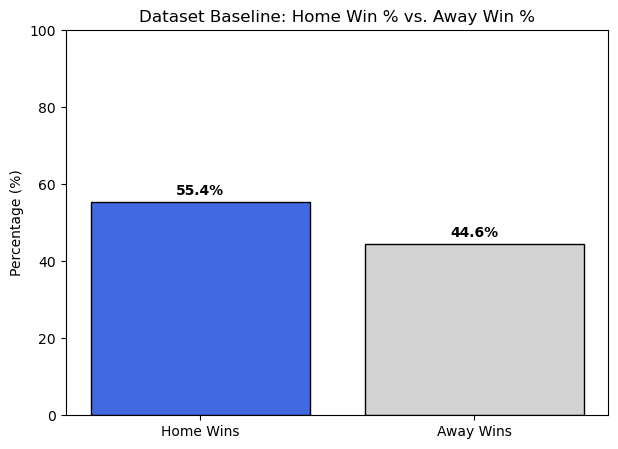

In [13]:
# Calculate percentages
home_win_pct = df['win'].mean() * 100
away_win_pct = (1 - df['win'].mean()) * 100

# Plotting
plt.figure(figsize=(7, 5))
labels = ['Home Wins', 'Away Wins']
values = [home_win_pct, away_win_pct]
colors = ['royalblue', 'lightgray']

bars = plt.bar(labels, values, color=colors, edgecolor='black')

# Formatting
plt.ylabel('Percentage (%)')
plt.title('Dataset Baseline: Home Win % vs. Away Win %')
plt.ylim(0, 100)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.show()

We find that the home team wins 55.4% of the time, which means that our model should do better than this to be useful.

# Modeling

First we will set aside the final twenty percent of games, in chronological order, as the test set. 

In [14]:
df = df.sort_values('gameDateTimeEst')
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

Now we'll split the train and test data into X and y.

In [15]:
X_train, y_train = train_df.drop(columns=['win', 'gameDateTimeEst']), train_df['win']
X_test, y_test = test_df.drop(columns=['win', 'gameDateTimeEst']), test_df['win']

Next, using a time series split, we will set up and fit and XGBoost model (an implementation of Gradient Boosting, which fits trees sequentially).

In [16]:
xgb_pipe = Pipeline([
    ('clf', XGBClassifier(random_state=4025, missing=np.nan)),
])

cv = TimeSeriesSplit(n_splits = 5)
num_iter = 150


xgb_params = {
    'clf__n_estimators':     randint(50, 400),
    'clf__learning_rate':    loguniform(1e-3, 0.5),
    'clf__max_depth':        randint(2, 10),
    'clf__min_child_weight': randint(1, 20),
}
xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_params, n_iter=num_iter, cv=cv,
    scoring='accuracy', return_train_score=True, random_state=4025,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'clf__learning_rate': <scipy.stats....x79d4fa4a2e40>, 'clf__max_depth': <scipy.stats....x79d4fa4aa5d0>, 'clf__min_child_weight': <scipy.stats....x79d4fa46c410>, 'clf__n_estimators': <scipy.stats....x79d4fa4a2270>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",150
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Ref

What's the average accuracy of our best model in cross validation?

In [17]:
print(xgb_search.best_score_)

0.6129850746268657


How does the model perform on the test set? 

In [18]:
test_preds = xgb_search.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)
print(f"Final Test Accuracy: {test_acc:.4f}")

Final Test Accuracy: 0.6249


# Performance Analysis

Our model has an accuracy of 61.3%, which easily beats the baseline of 55.4%. Further, this result holds on the test set (the most recent 20% of games), with an accuracy of 61.25%.

# Feature Importance

Now we'll examine the feature importances according to our model.

--- Feature Importance ---
diff_roll10_win                       0.317184
diff_roll10_teamScore                 0.061640
diff_roll10_opponentScore             0.060629
diff_roll10_threePointersMade         0.053907
diff_playedYesterday                  0.041636
diff_roll10_reboundsDefensive         0.040489
diff_hrSinceLastGame                  0.037916
diff_roll10_threePointersAttempted    0.037493
diff_roll10_steals                    0.037492
diff_roll10_fieldGoalsAttempted       0.037492
diff_roll10_foulsPersonal             0.036891
diff_roll10_fieldGoalsMade            0.036777
diff_roll10_turnovers                 0.034992
diff_roll10_reboundsOffensive         0.034370
diff_roll10_assists                   0.034059
diff_roll10_freeThrowsMade            0.034028
diff_roll10_blocks                    0.031873
diff_roll10_freeThrowsAttempted       0.031132
dtype: float32


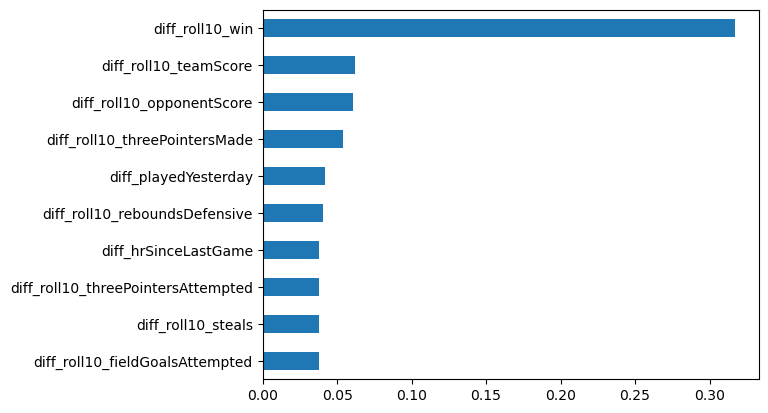

In [19]:
importances = xgb_search.best_estimator_.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
print("--- Feature Importance ---")
print(feat_imp)
feat_imp.head(10).plot(kind='barh').invert_yaxis()

The model is telling us that the teams' winning percentages in the last 10 games before the game in question is by far the most important feature for predicting which team will win. This variable inherently captures real world variables that are hard to quantify, making it's predictive power very high.

# Conclusion